# UMAP Visualization of Diffusion-LM Embeddings

Visualize how token embeddings cluster for:
- **e2e** (end-to-end trained) embeddings
- **emb** (frozen random) embeddings
- **init** (initial random) embeddings

Requires `embeddings_comparison.npz` produced by `extract_embeddings.py`.

In [1]:
!pip install -q umap-learn matplotlib

In [2]:
import json
import numpy as np
import umap
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# -- Configuration --
NPZ_PATH = "/content/drive/MyDrive/models/Diffusion-LM/embeddings_comparison.npz"

data = np.load(NPZ_PATH, allow_pickle=True)
emb_e2e = data["e2e"]
emb_frozen = data["emb"]
emb_init = data["init"]
vocab = json.loads(str(data["vocab"]))
id2word = {v: k for k, v in vocab.items()}
words = [id2word[i] for i in range(len(id2word))]

print(f"Vocab size: {len(words)}")
print(f"Embedding dim: {emb_e2e.shape[1]}")
print(f"Shapes  e2e={emb_e2e.shape}  frozen={emb_frozen.shape}  init={emb_init.shape}")

Vocab size: 821
Embedding dim: 64
Shapes  e2e=(821, 64)  frozen=(821, 64)  init=(821, 64)


## UMAP Projection

In [5]:
def fit_umap(embeddings, n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric=metric,
        random_state=random_state,
    )
    return reducer.fit_transform(embeddings)

In [6]:
print("Fitting UMAP on e2e embeddings...")
proj_e2e = fit_umap(emb_e2e)

print("Fitting UMAP on frozen (emb) embeddings...")
proj_frozen = fit_umap(emb_frozen)

print("Done.")

Fitting UMAP on e2e embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP on frozen (emb) embeddings...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


## Scatter Plots

Color = L2 drift of each token from its initialization (brighter = more drift).

In [7]:
drift = np.linalg.norm(emb_e2e - emb_init, axis=1)

def make_scatter(proj, title, color_values, color_label, figsize=(12, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=color_values, cmap="viridis",
                    s=10, alpha=0.7, edgecolors="none")
    plt.colorbar(sc, ax=ax, label=color_label)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.tight_layout()
    return fig, ax

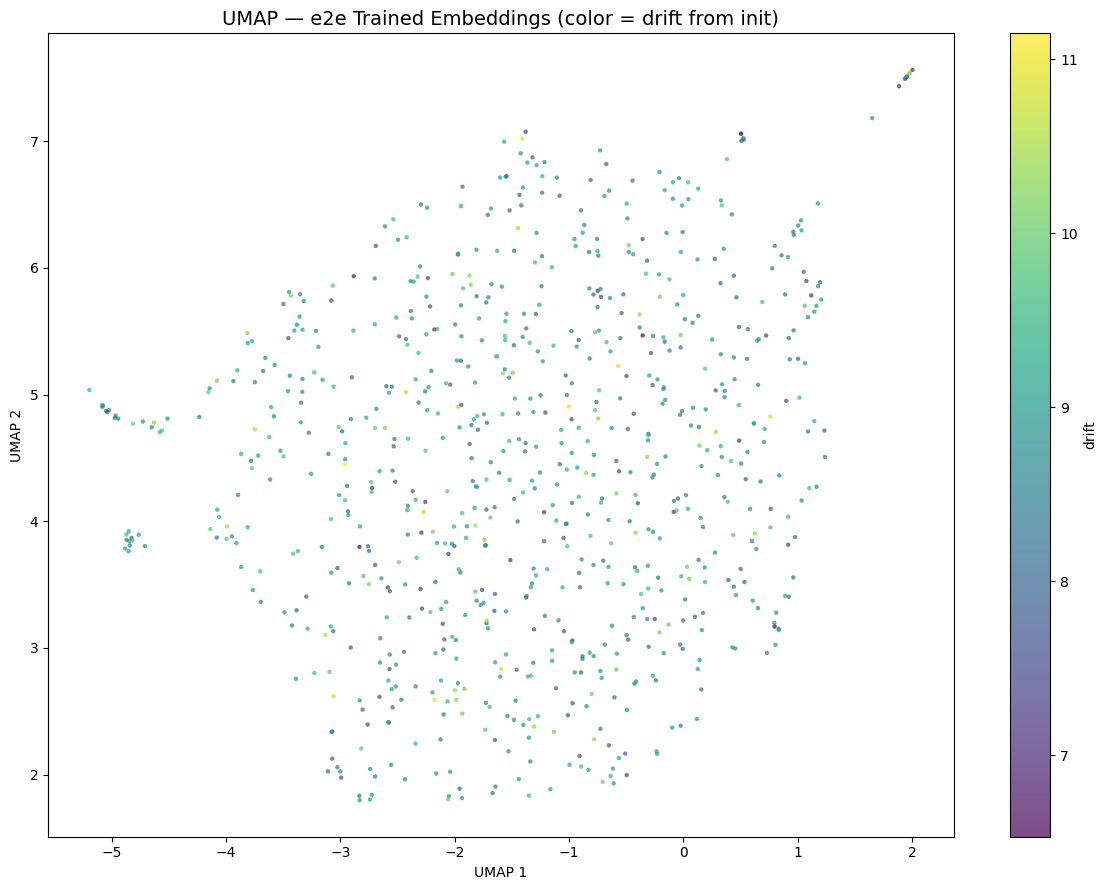

In [8]:
make_scatter(proj_e2e, "UMAP \u2014 e2e Trained Embeddings (color = drift from init)", drift, "drift")
plt.show()

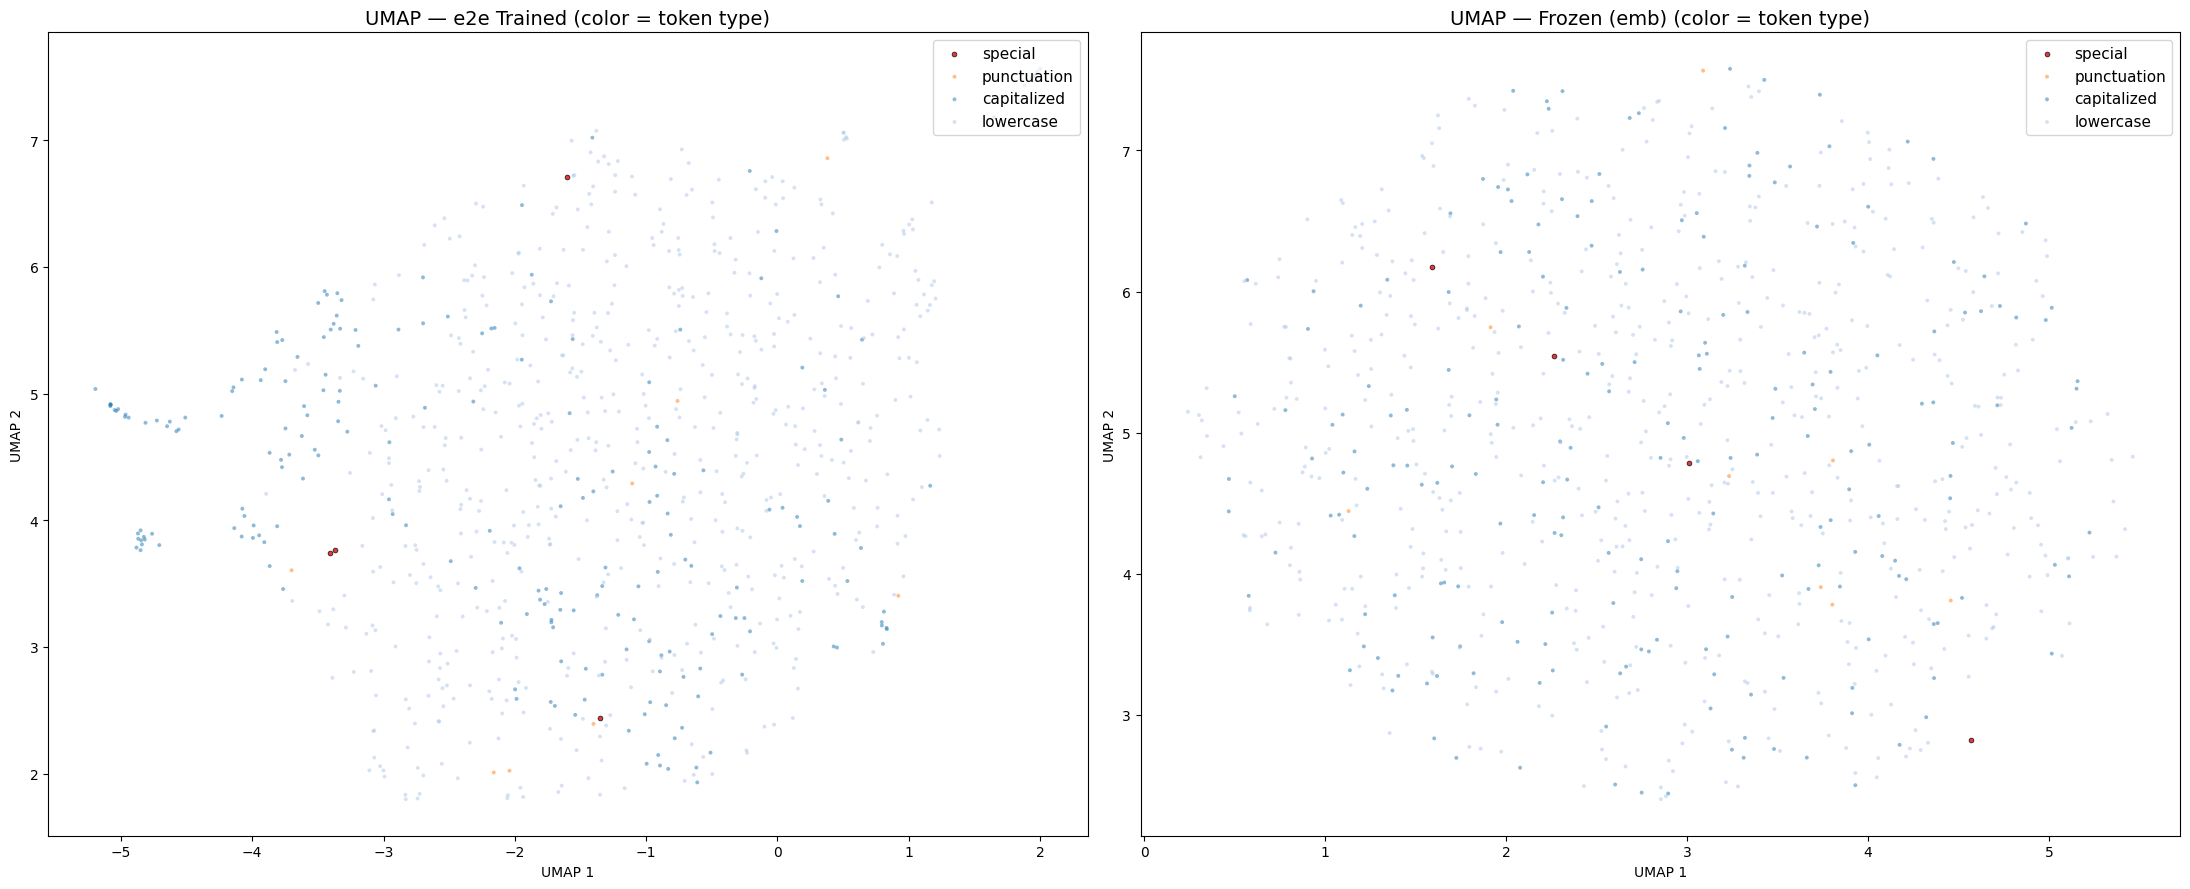

In [9]:
SPECIAL = {"START", "END", "UNK", "PAD"}
PUNCT = {".", ",", "-", "'", '"', ":", ";", "!", "?", "(", ")", "\n", ".."}

def categorize(token):
    if token in SPECIAL:
        return "special"
    if token in PUNCT:
        return "punctuation"
    if token[0].isupper():
        return "capitalized"
    return "lowercase"

categories = [categorize(w) for w in words]
cat_names = ["special", "punctuation", "capitalized", "lowercase"]
cat_colors = {"special": "#d62728", "punctuation": "#ff7f0e",
              "capitalized": "#1f77b4", "lowercase": "#aec7e8"}

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, proj, title in zip(axes,
                            [proj_e2e, proj_frozen],
                            ["e2e Trained", "Frozen (emb)"]):
    for cat in cat_names:
        idx = [i for i, c in enumerate(categories) if c == cat]
        ax.scatter(proj[idx, 0], proj[idx, 1],
                   s=12 if cat == "special" else 8,
                   alpha=0.9 if cat == "special" else 0.5,
                   label=cat, color=cat_colors[cat],
                   edgecolors="black" if cat == "special" else "none",
                   linewidths=0.5, zorder=10 if cat == "special" else 1)
    ax.legend(fontsize=11, loc="upper right")
    ax.set_title(f"UMAP \u2014 {title} (color = token type)", fontsize=14)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

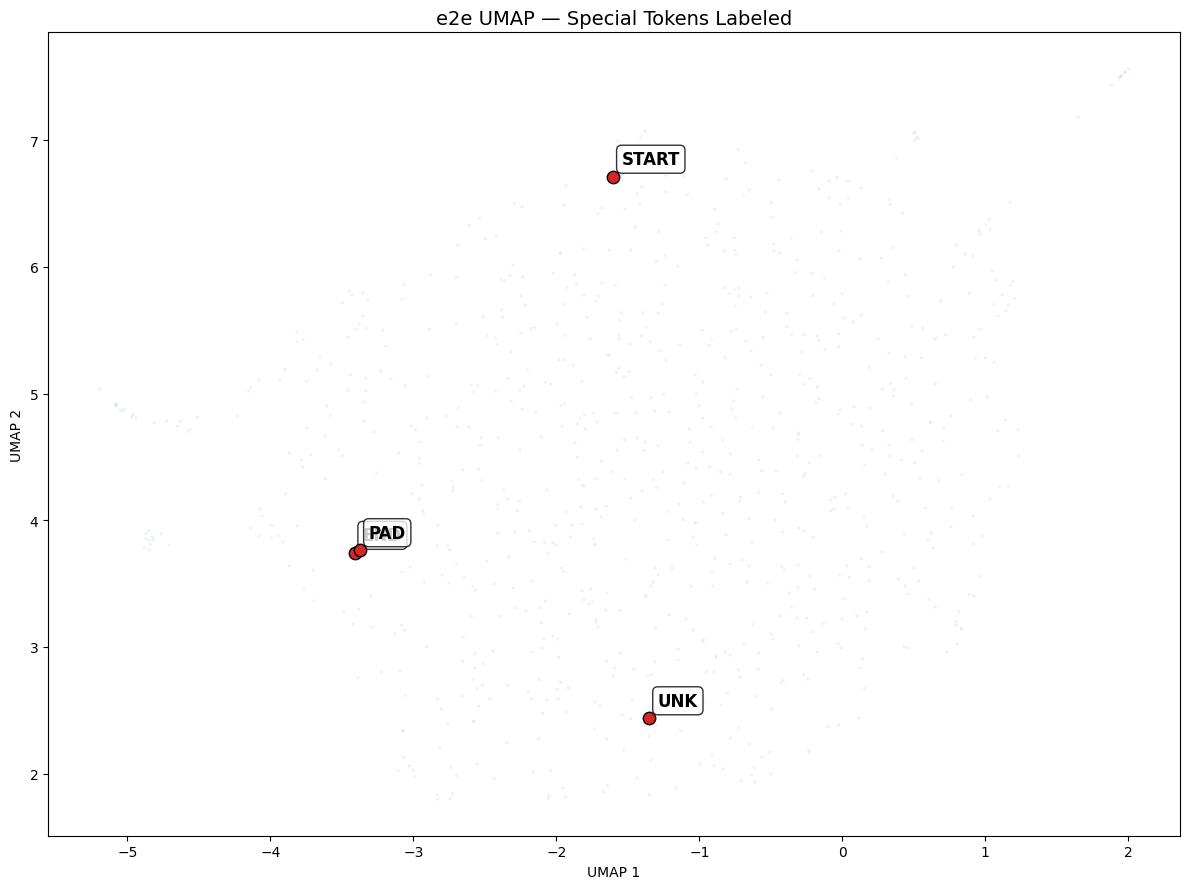


Pairwise cosine similarities between special tokens (e2e):
  START  <-> END     cos=0.0028  L2=7.4778
  START  <-> UNK     cos=-0.0446  L2=6.9105
  START  <-> PAD     cos=-0.0236  L2=8.5022
  END    <-> UNK     cos=-0.0083  L2=5.2533
  END    <-> PAD     cos=0.6182  L2=4.5927
  UNK    <-> PAD     cos=-0.1944  L2=6.9692


In [10]:
SPECIAL = {"START", "END", "UNK", "PAD"}
special_idx = [i for i, w in enumerate(words) if w in SPECIAL]

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(proj_e2e[:, 0], proj_e2e[:, 1], s=6, alpha=0.2,
           color="#aec7e8", edgecolors="none", label="other")

for i in special_idx:
    ax.scatter(proj_e2e[i, 0], proj_e2e[i, 1], s=80, color="#d62728",
               edgecolors="black", linewidths=1, zorder=10)
    ax.annotate(words[i], (proj_e2e[i, 0], proj_e2e[i, 1]),
                fontsize=12, fontweight="bold", ha="left", va="bottom",
                xytext=(6, 6), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

ax.set_title("e2e UMAP \u2014 Special Tokens Labeled", fontsize=14)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

print("\nPairwise cosine similarities between special tokens (e2e):")
for i, si in enumerate(special_idx):
    for j, sj in enumerate(special_idx):
        if j > i:
            cos = np.dot(emb_e2e[si], emb_e2e[sj]) / (np.linalg.norm(emb_e2e[si]) * np.linalg.norm(emb_e2e[sj]))
            dist = np.linalg.norm(emb_e2e[si] - emb_e2e[sj])
            print(f"  {words[si]:6s} <-> {words[sj]:6s}  cos={cos:.4f}  L2={dist:.4f}")

## Joint UMAP: e2e vs Frozen

Project both embedding sets together so they share the same coordinate space.

Fitting joint UMAP on 1642 points...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


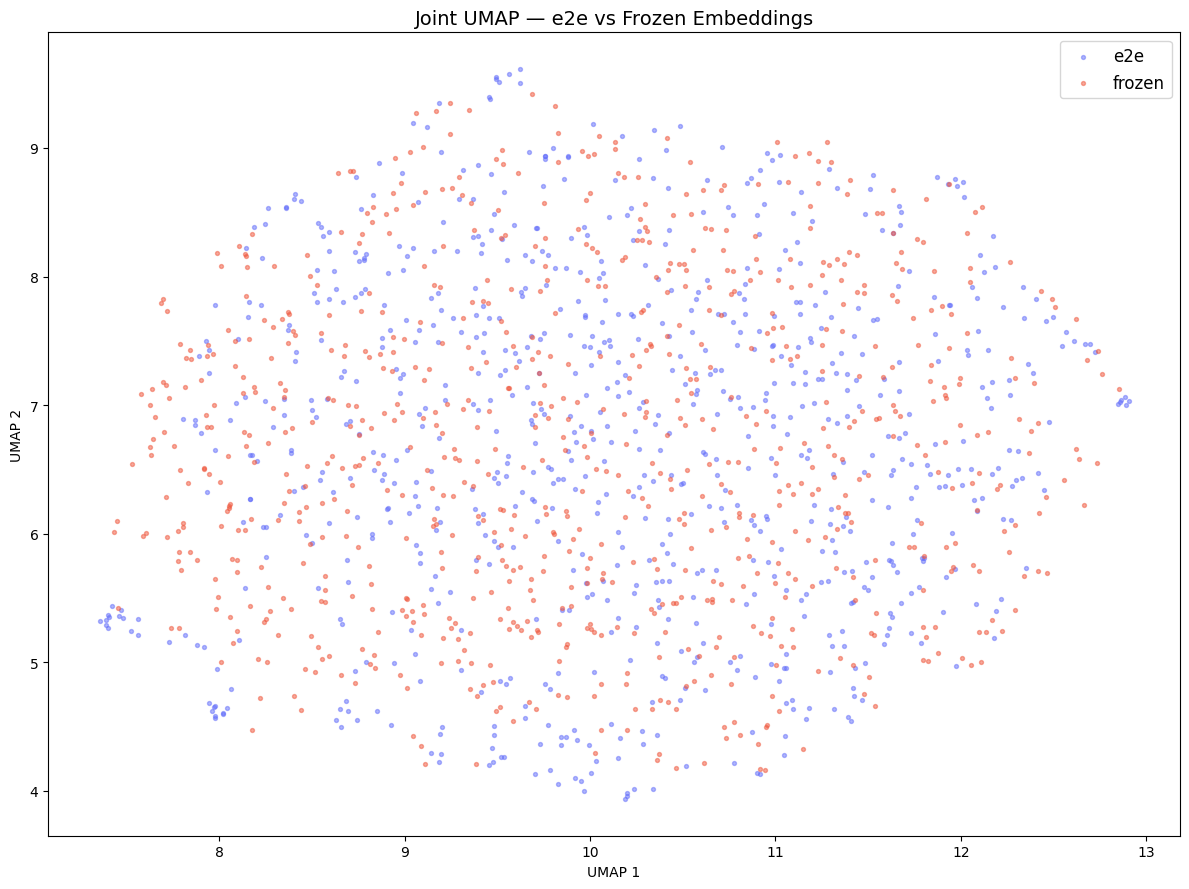

In [11]:
n = len(words)
stacked = np.vstack([emb_e2e, emb_frozen])

print(f"Fitting joint UMAP on {stacked.shape[0]} points...")
proj_joint = fit_umap(stacked)
print("Done.")

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(proj_joint[:n, 0], proj_joint[:n, 1],
           s=8, alpha=0.5, label="e2e", color="#636EFA")
ax.scatter(proj_joint[n:, 0], proj_joint[n:, 1],
           s=8, alpha=0.5, label="frozen", color="#EF553B")
ax.legend(fontsize=12)
ax.set_title("Joint UMAP \u2014 e2e vs Frozen Embeddings", fontsize=14)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## Top Movers: tokens that drifted most during e2e training

In [12]:
TOP_K = 30

top_idx = np.argsort(drift)[::-1][:TOP_K]
print(f"Top {TOP_K} tokens by L2 drift (e2e vs init):")
for rank, i in enumerate(top_idx, 1):
    print(f"  {rank:3d}. {words[i]:20s}  drift={drift[i]:.4f}")

Top 30 tokens by L2 drift (e2e vs init):
    1. small                 drift=11.1487
    2. corner                drift=10.9093
    3. see                   drift=10.8549
    4. 'll                   drift=10.8172
    5. Fast                  drift=10.8132
    6. Shop                  drift=10.7960
    7. rang                  drift=10.7527
    8. takeaway              drift=10.7464
    9. an                    drift=10.7212
   10. available             drift=10.6291
   11. services              drift=10.6039
   12. Crowne                drift=10.5735
   13. fruit                 drift=10.5377
   14. drinks                drift=10.5094
   15. Midsummer             drift=10.4930
   16. servers               drift=10.4665
   17. too                   drift=10.4547
   18. options               drift=10.4523
   19. full                  drift=10.4097
   20. recommended           drift=10.3788
   21. don                   drift=10.3757
   22. class                 drift=10.3608
   23. But   

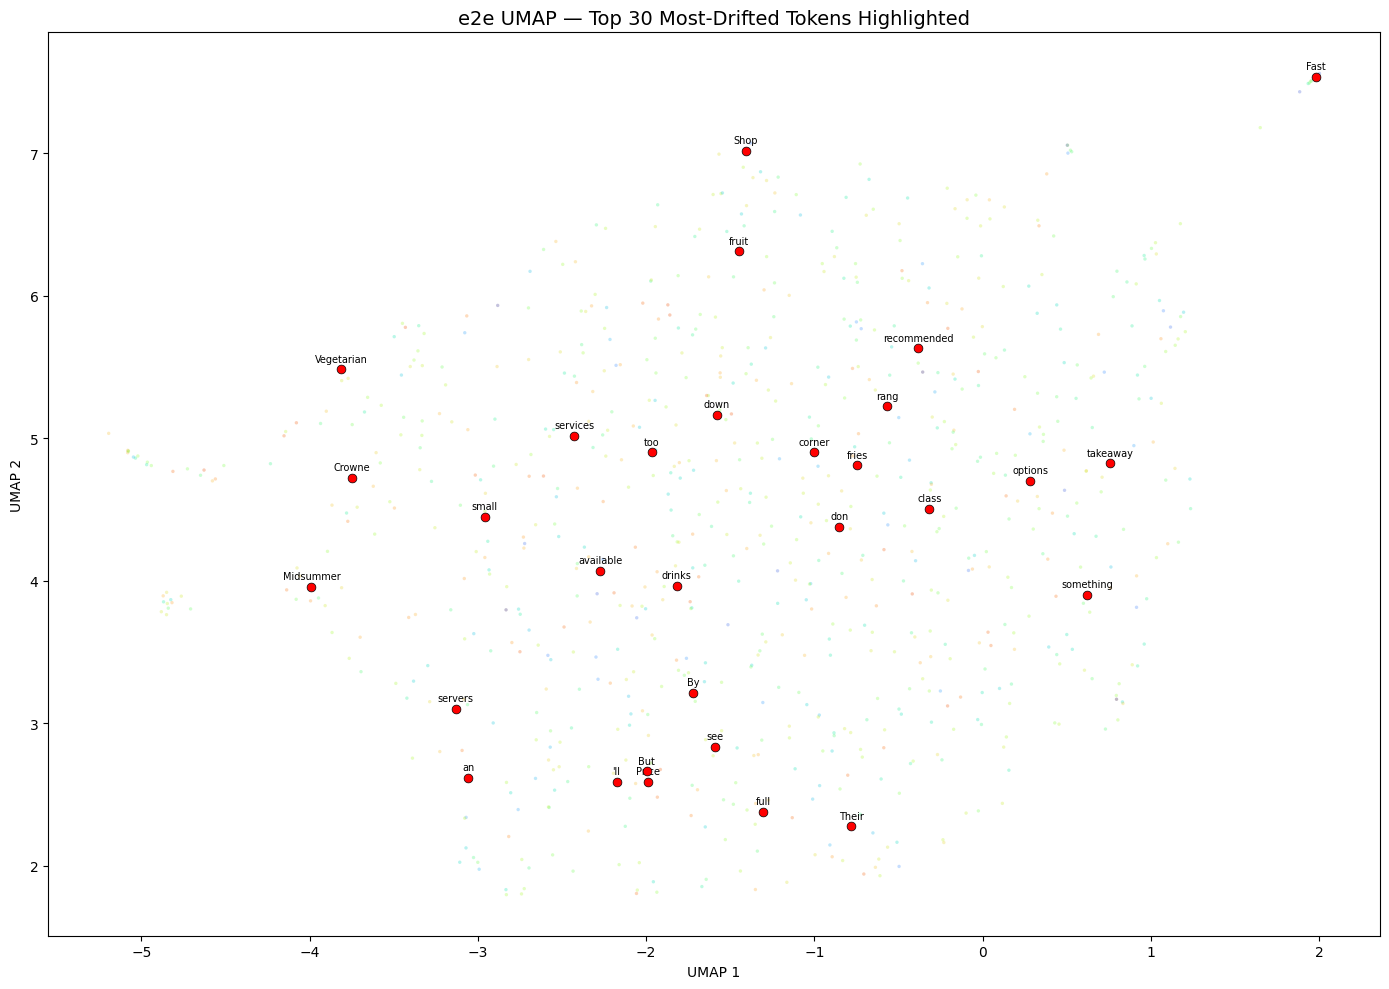

In [13]:
highlight_idx = set(top_idx)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(proj_e2e[:, 0], proj_e2e[:, 1], c=drift, cmap="turbo",
           s=6, alpha=0.3, edgecolors="none")

for i in top_idx:
    ax.scatter(proj_e2e[i, 0], proj_e2e[i, 1], c="red", s=40,
              edgecolors="black", linewidths=0.5, zorder=5)
    ax.annotate(words[i], (proj_e2e[i, 0], proj_e2e[i, 1]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")

ax.set_title(f"e2e UMAP \u2014 Top {TOP_K} Most-Drifted Tokens Highlighted", fontsize=14)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

## Export for TensorFlow Embedding Projector

Generates TSV files you can load at [projector.tensorflow.org](https://projector.tensorflow.org/):
1. Click **Load** in the left panel
2. Upload the vectors TSV and metadata TSV
3. Explore with UMAP/t-SNE/PCA, search tokens, see neighbors

In [ ]:
import os

OUT_DIR = os.path.dirname(NPZ_PATH)

def export_projector_tsv(embeddings, words, prefix, out_dir):
    vec_path = os.path.join(out_dir, f"{prefix}_vectors.tsv")
    meta_path = os.path.join(out_dir, f"{prefix}_metadata.tsv")

    with open(vec_path, "w") as f:
        for row in embeddings:
            f.write("\t".join(str(x) for x in row) + "\n")

    with open(meta_path, "w") as f:
        for w in words:
            f.write(w.replace("\n", "<NL>") + "\n")

    print(f"  {vec_path}  ({embeddings.shape})")
    print(f"  {meta_path}  ({len(words)} labels)")

print("Exporting e2e embeddings...")
export_projector_tsv(emb_e2e, words, "e2e", OUT_DIR)

print("\nExporting frozen embeddings...")
export_projector_tsv(emb_frozen, words, "frozen", OUT_DIR)

print("\nDone! Upload these at https://projector.tensorflow.org/")
print("  - Click 'Load' on the left panel")
print("  - Step 1: choose the *_vectors.tsv file")
print("  - Step 2: choose the *_metadata.tsv file")